# 🎬 IMDB Sentiment Analysis — NLP Pipeline
**Columns:** `review`, `sentiment` | **Algorithms:** NB · LR · SVM · Ensemble Voting

In [14]:
import pandas as pd, numpy as np, re, os, joblib, warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_auc_score,roc_curve
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
for p in ['punkt','stopwords','wordnet','omw-1.4','punkt_tab']: nltk.download(p,quiet=True)
plt.style.use('seaborn-v0_8-darkgrid'); SEED=42
print('✅ Imports OK')

✅ Imports OK


## 1. Load Dataset

In [15]:
try:
    df = pd.read_csv('../data/IMDB Dataset.csv')
    print(f'Loaded {df.shape[0]:,} rows')
except FileNotFoundError:
    print('⚠️  Dataset not found — using synthetic demo. Download from Kaggle:')
    print('   https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')
    rows = [
        ('This movie was absolutely fantastic! Brilliant acting and superb direction.','positive'),
        ('An emotional masterpiece. One of the greatest films ever made.','positive'),
        ('Wonderful performances and a deeply moving story. Highly recommended.','positive'),
        ('Incredible cinematography and a captivating plot from start to finish.','positive'),
        ('Terrible film. Boring, predictable and a complete waste of time.','negative'),
        ('Awful script, wooden acting, no redeeming qualities whatsoever.','negative'),
        ('A disappointing mess that ruins the legacy of the original.','negative'),
        ('Poorly directed, poorly written, I walked out after 20 minutes.','negative'),
    ] * 250
    df = pd.DataFrame(rows, columns=['review','sentiment'])
print(df.head(3))
print(df['sentiment'].value_counts())

Loaded 50,000 rows
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


## 2. EDA

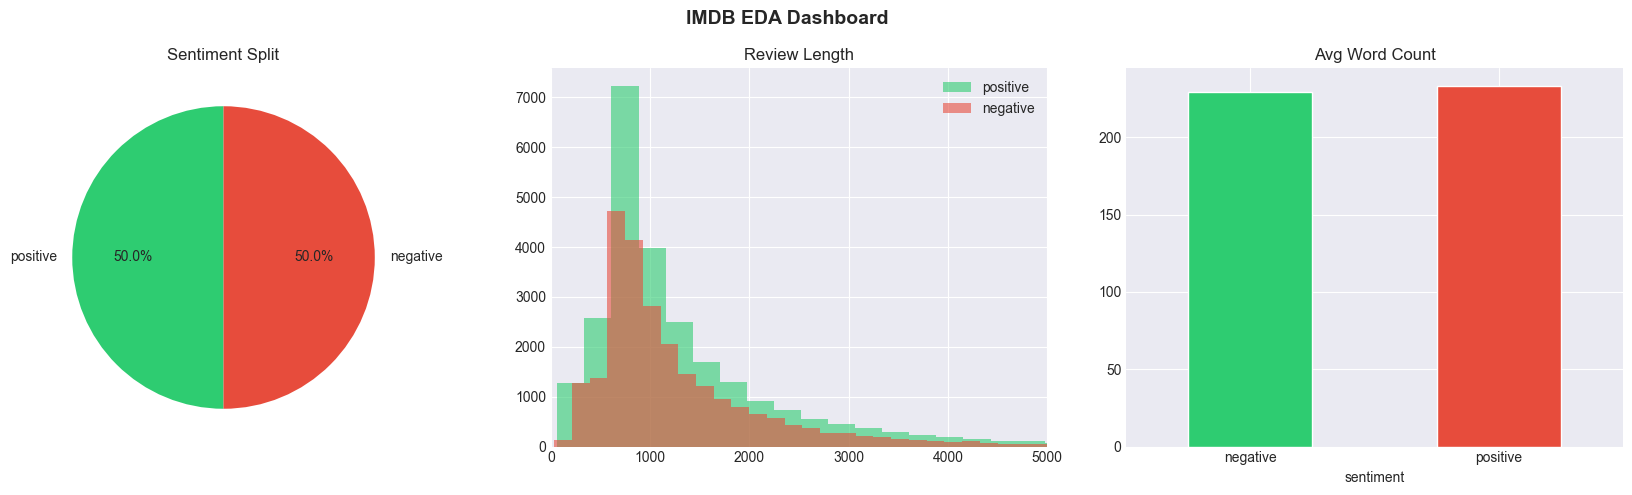

In [16]:
df['review_len'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))
fig,axes = plt.subplots(1,3,figsize=(17,5))
fig.suptitle('IMDB EDA Dashboard',fontsize=14,fontweight='bold')
cnt = df['sentiment'].value_counts()
axes[0].pie(cnt,labels=cnt.index,autopct='%1.1f%%',colors=['#2ecc71','#e74c3c'],startangle=90)
axes[0].set_title('Sentiment Split')
for s,c in zip(['positive','negative'],['#2ecc71','#e74c3c']):
    axes[1].hist(df[df['sentiment']==s]['review_len'],bins=50,alpha=0.6,label=s,color=c)
axes[1].set_title('Review Length'); axes[1].legend(); axes[1].set_xlim(0,5000)
df.groupby('sentiment')['word_count'].mean().plot(kind='bar',ax=axes[2],color=['#2ecc71','#e74c3c'],edgecolor='w')
axes[2].set_title('Avg Word Count'); axes[2].tick_params(axis='x',rotation=0)
plt.tight_layout()
os.makedirs('../app/static',exist_ok=True)
plt.savefig('../app/static/eda.png',dpi=130,bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [17]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {'no','not','nor','never','nothing',"n't",'cannot'}

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>',' ',text)
    text = re.sub(r"[^a-z']",' ',text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t)>2]
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

print('⏳ Preprocessing...')
df['cleaned'] = df['review'].apply(preprocess)
df['label']   = (df['sentiment']=='positive').astype(int)
print('✅ Done')
print(df[['review','cleaned','label']].head(2))

⏳ Preprocessing...
✅ Done
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   

                                             cleaned  label  
0  one reviewer mentioned watching episode 'll ho...      1  
1  wonderful little production filming technique ...      1  


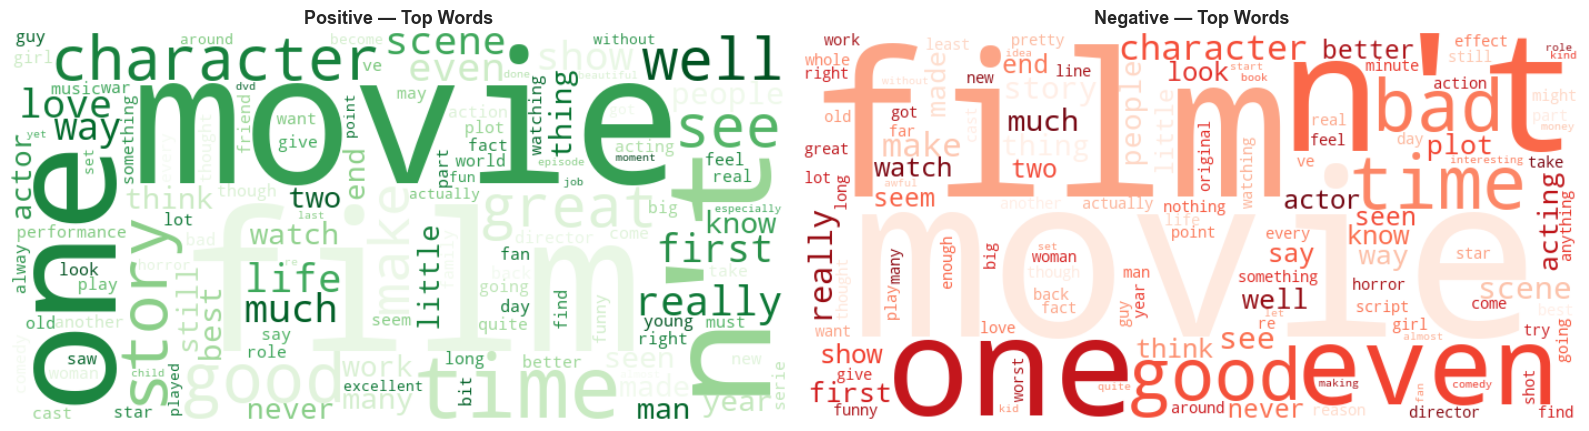

In [18]:
fig,axes = plt.subplots(1,2,figsize=(16,6))
for ax,sent,cmap in zip(axes,['positive','negative'],['Greens','Reds']):
    corpus=' '.join(df[df['sentiment']==sent]['cleaned'])
    wc=WordCloud(width=700,height=350,background_color='white',colormap=cmap,
                 max_words=120,collocations=False).generate(corpus)
    ax.imshow(wc,interpolation='bilinear'); ax.axis('off')
    ax.set_title(f'{sent.title()} — Top Words',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('../app/static/wordclouds.png',dpi=130,bbox_inches='tight')
plt.show()

## 4. TF-IDF + Train/Test Split

In [19]:
X,y = df['cleaned'], df['label']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=SEED)
tfidf = TfidfVectorizer(ngram_range=(1,2),max_features=50000,min_df=3,max_df=0.92,sublinear_tf=True)
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)
print(f'Train: {Xtr.shape}  Test: {Xte.shape}')

Train: (40000, 50000)  Test: (10000, 50000)


## 5. Train Models

In [20]:
models = {
    'Naive Bayes'          : MultinomialNB(alpha=0.1),
    'Logistic Regression'  : LogisticRegression(C=1.0,max_iter=1000,random_state=SEED),
    'Support Vector Machine': CalibratedClassifierCV(LinearSVC(C=1.0,max_iter=2000,random_state=SEED))
}
results,trained = {},{}
for name,model in models.items():
    print(f'⏳ {name}...')
    model.fit(Xtr,y_train)
    yp = model.predict(Xte)
    ypr= model.predict_proba(Xte)[:,1]
    results[name]={'Accuracy':accuracy_score(y_test,yp),'Precision':precision_score(y_test,yp),
                   'Recall':recall_score(y_test,yp),'F1':f1_score(y_test,yp),
                   'AUC':roc_auc_score(y_test,ypr),'yp':yp,'ypr':ypr}
    trained[name]=model
    print(f'   Acc={results[name]["Accuracy"]:.4f} F1={results[name]["F1"]:.4f}')

⏳ Naive Bayes...
   Acc=0.8826 F1=0.8836
⏳ Logistic Regression...
   Acc=0.9052 F1=0.9061
⏳ Support Vector Machine...
   Acc=0.9107 F1=0.9110


In [21]:
ensemble = VotingClassifier(
    [('nb',MultinomialNB(alpha=0.1)),
     ('lr',LogisticRegression(C=1.0,max_iter=1000,random_state=SEED)),
     ('svm',CalibratedClassifierCV(LinearSVC(C=1.0,max_iter=2000,random_state=SEED)))],
    voting='soft',weights=[1,2,2])
ensemble.fit(Xtr,y_train)
yp=ensemble.predict(Xte); ypr=ensemble.predict_proba(Xte)[:,1]
results['Ensemble']={'Accuracy':accuracy_score(y_test,yp),'F1':f1_score(y_test,yp),'AUC':roc_auc_score(y_test,ypr),'yp':yp,'ypr':ypr}
trained['Ensemble']=ensemble
print(f'Ensemble → Acc={results["Ensemble"]["Accuracy"]:.4f} F1={results["Ensemble"]["F1"]:.4f}')

Ensemble → Acc=0.9145 F1=0.9152


## 6. Evaluation

In [22]:
metric_keys=['Accuracy','Precision','Recall','F1']
mdf=pd.DataFrame({n:{k:round(v,4) for k,v in m.items() if k in metric_keys} for n,m in results.items() if 'Accuracy' in m}).T
print(mdf.sort_values('F1',ascending=False).to_string())

                        Accuracy  Precision  Recall      F1
Ensemble                  0.9145        NaN     NaN  0.9152
Support Vector Machine    0.9107     0.9083  0.9136  0.9110
Logistic Regression       0.9052     0.8974  0.9150  0.9061
Naive Bayes               0.8826     0.8760  0.8914  0.8836


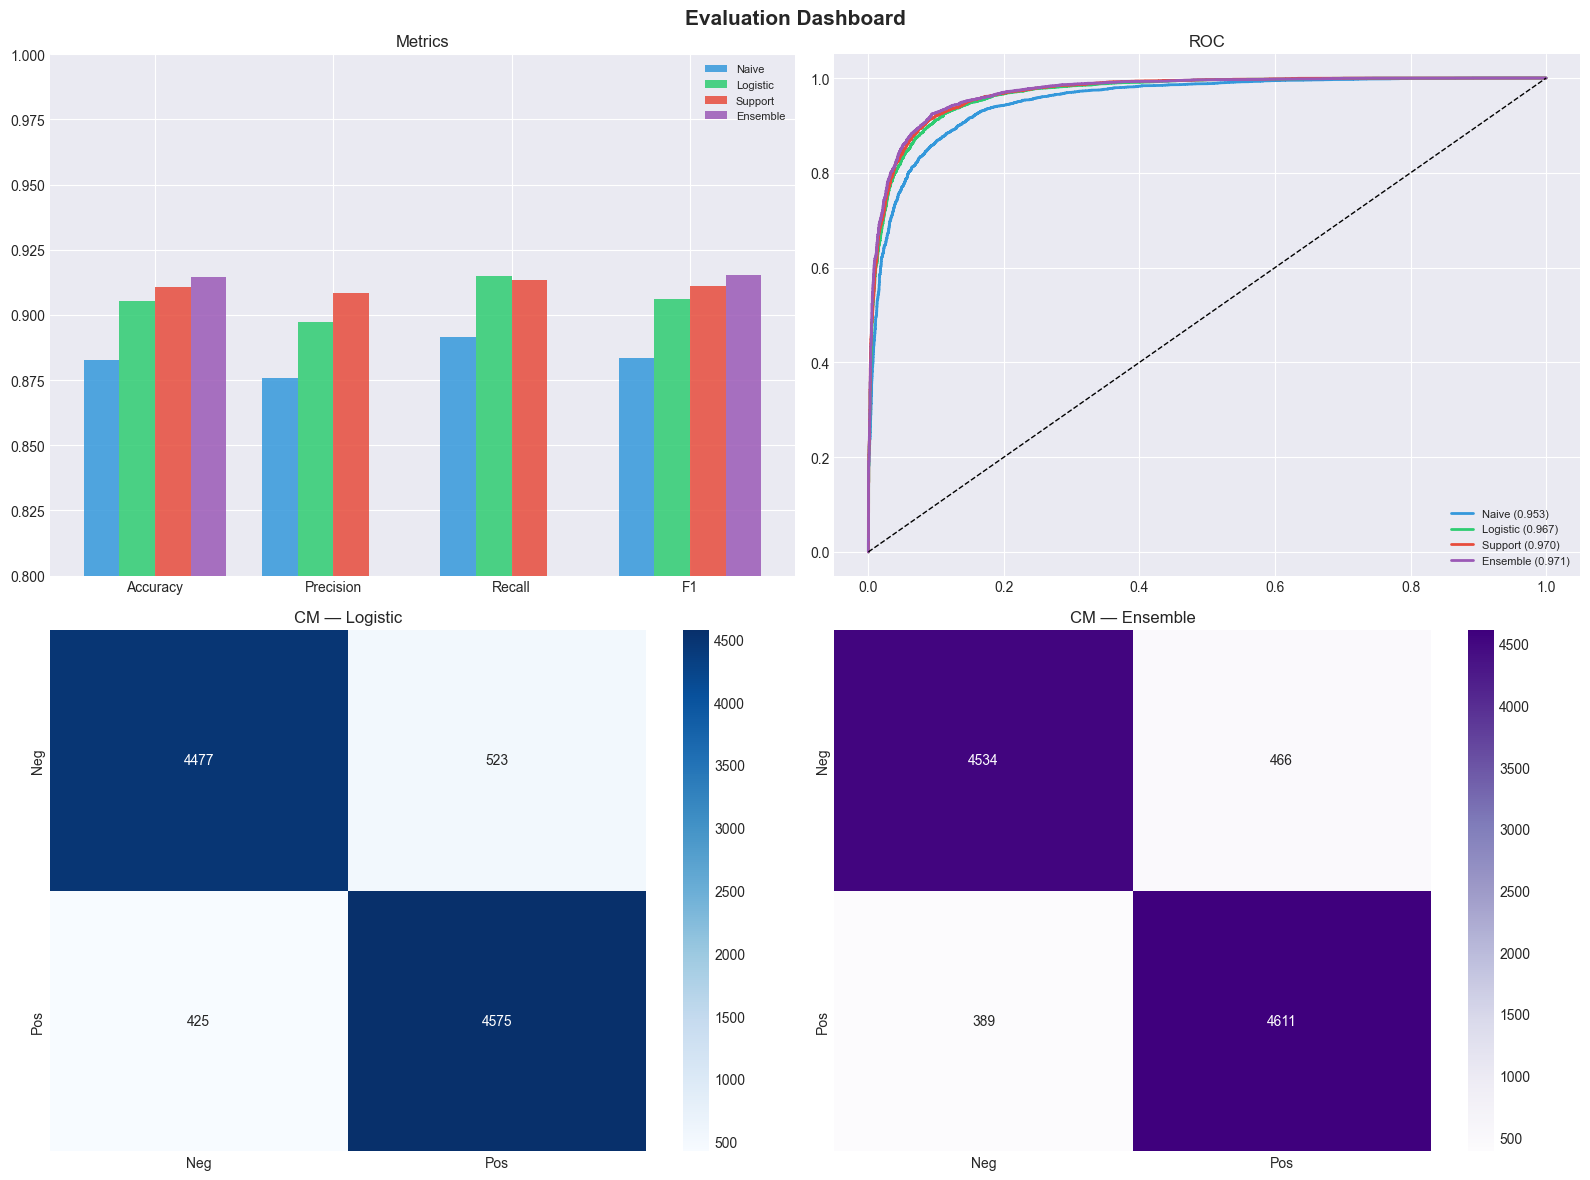

In [23]:
fig,axes=plt.subplots(2,2,figsize=(16,12))
fig.suptitle('Evaluation Dashboard',fontsize=15,fontweight='bold')
colors=['#3498db','#2ecc71','#e74c3c','#9b59b6']
mnames=list(results.keys())
# grouped bar
x=np.arange(4); w=0.2; ml=['Accuracy','Precision','Recall','F1']
for i,(nm,c) in enumerate(zip(mnames,colors)):
    vals=[results[nm].get(m,0) for m in ml]
    axes[0,0].bar(x+i*w,vals,w,label=nm.split()[0],color=c,alpha=0.85)
axes[0,0].set_xticks(x+w*1.5); axes[0,0].set_xticklabels(ml)
axes[0,0].set_ylim(0.8,1); axes[0,0].set_title('Metrics'); axes[0,0].legend(fontsize=8)
# ROC
for (nm,m),c in zip(results.items(),colors):
    fpr,tpr,_=roc_curve(y_test,m['ypr'])
    axes[0,1].plot(fpr,tpr,label=f'{nm.split()[0]} ({m["AUC"]:.3f})',color=c,lw=2)
axes[0,1].plot([0,1],[0,1],'k--',lw=1); axes[0,1].set_title('ROC'); axes[0,1].legend(fontsize=8)
# Confusion matrices
for ax,nm,cmap in zip([axes[1,0],axes[1,1]],[mnames[1],'Ensemble'],['Blues','Purples']):
    cm=confusion_matrix(y_test,results[nm]['yp'])
    sns.heatmap(cm,annot=True,fmt='d',cmap=cmap,xticklabels=['Neg','Pos'],yticklabels=['Neg','Pos'],ax=ax)
    ax.set_title(f'CM — {nm.split()[0]}')
plt.tight_layout()
plt.savefig('../app/static/eval.png',dpi=130,bbox_inches='tight')
plt.show()

## 7. Cross-Validation

In [24]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
Xall=tfidf.transform(X)
cv_res={}
for nm,model in [('Naive Bayes',MultinomialNB(alpha=0.1)),
                  ('Logistic Regression',LogisticRegression(C=1.0,max_iter=1000,random_state=SEED)),
                  ('SVM',CalibratedClassifierCV(LinearSVC(C=1.0,max_iter=2000,random_state=SEED)))]:
    scores=cross_val_score(model,Xall,y,cv=cv,scoring='f1',n_jobs=-1)
    cv_res[nm]=scores
    print(f'{nm}: F1={scores.mean():.4f} ± {scores.std():.4f}')

Naive Bayes: F1=0.8868 ± 0.0038
Logistic Regression: F1=0.9047 ± 0.0018
SVM: F1=0.9084 ± 0.0016


## 8. Save Models

In [25]:
os.makedirs('../models',exist_ok=True)
joblib.dump(tfidf,              '../models/tfidf_vectorizer.pkl')
joblib.dump(trained['Naive Bayes'],           '../models/naive_bayes.pkl')
joblib.dump(trained['Logistic Regression'],   '../models/logistic_regression.pkl')
joblib.dump(trained['Support Vector Machine'],'../models/svm.pkl')
joblib.dump(trained['Ensemble'],              '../models/ensemble.pkl')
# sentiment_model.pkl = best model alias
joblib.dump(trained['Ensemble'],              '../models/sentiment_model.pkl')
print('✅ Saved:', os.listdir('../models/'))

✅ Saved: ['ensemble.pkl', 'logistic_regression.pkl', 'naive_bayes.pkl', 'sentiment_model.pkl', 'svm.pkl', 'tfidf_vectorizer.pkl']


## 9. Inference Demo

In [26]:
def predict(text, model=None, vec=None):
    if model is None: model = trained['Ensemble']
    if vec   is None: vec   = tfidf
    c = preprocess(text)
    f = vec.transform([c])
    p = model.predict(f)[0]
    pr= model.predict_proba(f)[0]
    return {'sentiment':'positive' if p==1 else 'negative',
            'confidence':round(float(pr[p])*100,2)}

for r in ['Absolutely breathtaking film, a true masterpiece!',
           'Terrible — boring, slow, a complete waste of time.']:
    res=predict(r)
    print(f'[{res["sentiment"].upper():8s} {res["confidence"]:5.1f}%] {r[:60]}')

[POSITIVE  90.7%] Absolutely breathtaking film, a true masterpiece!
[NEGATIVE  99.9%] Terrible — boring, slow, a complete waste of time.
